# Simulating Black Hole Images

This notebook lets you simulate a black hole image. All the code is already
written for generating a simlated picture of a spherical light source around a
Schwarzschild black hole. To generate different types of images, just change the
relevant bits of code to vary the parameters. (And if you're unsure how a bit of
code works, just ask!)

The next bit of code imports the relevant functions that we need for the
simulations. You (most likely) won't ever have to change anything here.

In [1]:
# FUNCTION IMPORTS -- DO NOT CHANGE

#pip install orbyts_black_hole_shadows

# We need to import three classes from the package: Metric, Box, and Source
from orbyts_black_hole_shadows.utils import Metric
from orbyts_black_hole_shadows.sources import Source, Box
import numpy as np

## Specifying a metric

This is the section that you will want to edit to vary the black hole metric!

The black hole metric will have the form:

$ds^2 = -A c^2 dt^2 + \frac{dr^2}{B} + r^2 d\Omega^2$,

To define the metric by defining A and B, use the code in the cell below, in 
units where $R_s=1$.

In [4]:
# Specify the metric here

def A(r):
    return 1-1/r
def B(r):
    return 1-1/r
def dAdr(r):
    return 1/r**2
def dBdr(r):
    return 1/r**2

metric = Metric(A,B,dAdr,dBdr)

In [2]:
# Run this cell instead for EsGB gravity black holes!
# Do not run it if you are doing GR and varying the shapes!
a = 0

def A2(r):
    return -49/(5*r)-49/(5*r**2)-137/(15*r**3)-7/(15*r**4)+26/(15*r**5)+10/(3*r**6)

def B2(r):
    return 49/(5*r)+29/(5*r**2)+19/(5*r**3)-203/(15*r**4)-218/(15*r**5)-46/(3*r**6)

def dA2dr(r):
    return 49/(5*r)+98/(5*r**3)+137/(5*r**4)+28/(15*r**5)-26/(3*r**6)-20/r**7

def dB2dr(r):
    return -49/(5*r**2)-58/(5*r**3)-57/(5*r**4)+812/(15*r**5)+218/(3*r**6)+92/r**7

def A(r):
    return (1-1/r)*(1+A2(r)*a**2)**2

def B(r):
    return (1-1/r)*(1+B2(r)*a**2)**(-2)

def dAdr(r):
    return 1/r**2*(1+A2(r)*a**2)**2 + 2*(1-1/r)*(1+A2(r)*a**2)*dA2dr(r)*a**2

def dBdr(r):
    return 1/r**2*(1+B2(r)*a**2)**2 - 2*(1-1/r)*(1+B2(r)*a**2)**(-3)*dB2dr(r)*a**2

metric = Metric(A,B,dAdr,dBdr)

## Specifying a source

This is the section to edit for specifying a shape of the source!

To define the light source we use the **`Source()`** class. We need to define a 
condition determining whether a given point is in the source. We can do this in 
different coordinate systems. Below are examples of a sphere or a disc as a
source. You can change the sizes of this sphere or disc. If you have ideas for 
completely different shapes that you'd like to try, you can define them if you 
can or ask for help to learn how to do this!

In later sections, you can also change the viewing angle of the source to e.g. 
rotate the disc relative to us.

Remember that it's best to vary one thing at a time to not mix the effects of
different parameters!

In [5]:
def is_in_star(point, R=1.0, r_in=None, t=0.5):
    """
    Returns True if the point (x, y, z) lies inside a 3D 5-pointed star.

    The star is defined in cylindrical polar coordinates (r, θ, z):
      - In the r-θ plane it is a regular 5-pointed star polygon.
      - In z it has uniform thickness t, centred on z = 0.

    Parameters
    ----------
    point : array-like, shape (3,)
        Cartesian coordinates (x, y, z) of the point to test.
    R     : float
        Outer radius — distance from the centre to each of the 5 tips.
    r_in  : float or None
        Inner radius — distance from the centre to each of the 5 valleys.
        Defaults to the canonical value for a regular star: R·(3−√5)/2 ≈ 0.382·R.
    t     : float
        Total thickness of the star in the z-direction.

    Returns
    -------
    bool
        True if the point is inside (or on the boundary of) the star.
    """
    x, y, z = point

    # Default inner radius for a regular 5-pointed star
    if r_in is None:
        r_in = R * (3.0 - np.sqrt(5.0)) / 2.0   # ≈ 0.382 · R

    # ------------------------------------------------------------------ #
    # 1. Z-axis check: the star has thickness t, centred on z = 0         #
    # ------------------------------------------------------------------ #
    if abs(z) > t / 2.0:
        return False

    # ------------------------------------------------------------------ #
    # 2. Radial / angular check in the r-θ plane                          #
    # ------------------------------------------------------------------ #
    r = np.sqrt(x**2 + y**2)

    # The centre is always inside
    if r == 0.0:
        return True

    n            = 5
    sector       = 2.0 * np.pi / n   # full sector: 72°
    half_sector  = np.pi / n          # half sector: 36°

    # Map θ into [0, sector) — the star looks identical in every sector
    theta = np.arctan2(y, x) % sector

    # Reflect into the first half-sector [0, half_sector] — the star edge
    # is symmetric about the mid-line of each sector
    if theta > half_sector:
        theta = sector - theta

    # ------------------------------------------------------------------ #
    # 3. Boundary radius at angle θ                                       #
    #                                                                      #
    # The star edge between the outer tip   (R,    0)                     #
    # and the inner valley (r_in, half_sector) is a straight line.        #
    # Intersecting that line with the ray at angle θ gives:               #
    #                                                                      #
    #          R · r_in · sin(α)                                          #
    # r_b = ─────────────────────────────────   where α = half_sector     #
    #        r_in · sin(α − θ) + R · sin(θ)                              #
    #                                                                      #
    # Edge cases: θ=0 → r_b = R  (outer tip)  ✓                          #
    #             θ=α → r_b = r_in (inner valley) ✓                      #
    # ------------------------------------------------------------------ #
    alpha = half_sector
    r_boundary = (R * r_in * np.sin(alpha)) / (
        r_in * np.sin(alpha - theta) + R * np.sin(theta)
    )

    return r <= r_boundary

def is_in_triangle(point, R=1.0, t=0.5):
    """
    Returns True if the point (x, y, z) lies inside a 3D equilateral triangle
    (triangular prism with zero-centred thickness).

    Parameters
    ----------
    point : array-like, shape (3,)
        Cartesian coordinates (x, y, z) of the point to test.
    R     : float
        Circumradius — distance from the centre to each vertex.
    t     : float
        Total thickness of the shape in the z-direction.

    Returns
    -------
    bool
        True if the point is inside (or on the boundary of) the triangle.
    """
    x, y, z = point

    # ------------------------------------------------------------------ #
    # 1. Z-axis check                                                      #
    # ------------------------------------------------------------------ #
    if abs(z) > t / 2.0:
        return False

    # ------------------------------------------------------------------ #
    # 2. Generate the 3 vertices of the equilateral triangle               #
    #    equally spaced at angles 90°, 210°, 330°  (one tip points up)    #
    # ------------------------------------------------------------------ #
    n        = 3
    angles   = [np.pi / 2.0 + 2.0 * np.pi * k / n for k in range(n)]
    vertices = [(R * np.cos(a), R * np.sin(a)) for a in angles]

    # ------------------------------------------------------------------ #
    # 3. Half-plane test for each edge                                     #
    #                                                                      #
    # For edge from vertex A to vertex B, the inward-pointing normal       #
    # can be evaluated via the cross product sign. A point P is on the     #
    # interior side when:                                                  #
    #                                                                      #
    #   (B - A) × (P - A)  ≥  0                                           #
    #                                                                      #
    # (using the z-component of the 3-D cross product, i.e. the 2-D       #
    # "signed area" / perp-dot-product)                                   #
    # ------------------------------------------------------------------ #
    for i in range(n):
        ax, ay = vertices[i]
        bx, by = vertices[(i + 1) % n]

        cross = (bx - ax) * (y - ay) - (by - ay) * (x - ax)
        if cross < 0:
            return False

    return True

def is_in_cuboid(point, a=1, b=1, c=1):
    """
    Returns True if the point (x, y, z) lies inside a 3D equilateral triangle
    (triangular prism with zero-centred thickness).

    Parameters
    ----------
    point : array-like, shape (3,)
        Cartesian coordinates (x, y, z) of the point to test.
    a     : float
        Length in the x direction
    b     : float
        Length in the y direction
    c     : float
        Length in the z direction

    Returns
    -------
    bool
        True if the point is inside (or on the boundary of) the triangle.
    """
    x, y, z = point

    if abs(x) > a / 2.0:
        return False
    
    elif abs(y) > b / 2.0:
        return False
    
    elif abs(z) > c / 2.0:
        return False
    
    else:
        return True

In [3]:
# You can specify sources here. Some examples are given

# Sphere of radius 5, change this number to make the sphere larger or smaller
sphere = Source(condition=lambda x: x[0] < 5, coordinates="Spherical")

# Disc of inner radius 2 and outer radius 5 with thickness 1
disc = Source(condition=lambda x: -0.5 < x[2] < 0.5 and 2 < x[0] < 5, coordinates="Cylindrical")

# Star
star = Source(condition=lambda x: is_in_star(x, R=5, r_in=None, t=0.5), coordinates="Cartesian")

# Triangle
triangle = Source(condition=lambda x: is_in_triangle(x, R=5, t=1), coordinates="Cartesian")

# Cuboid
cuboid = Source(condition=lambda x: is_in_cuboid(x, a=5, b=5, c=5), coordinates="Cartesian")

## Calculating Light Trajectories

Finally, we use the **`Box()`** class to define the box in which our black hole 
and source live, and use it to do the required calculations for simulating a
shadow. Starting with the example of the spherical source at low resolution for 
quick runs.

__You might have to change things here if you changed the source to ensure it 
still fits inside the box!__ Most importantly, make sure that the light rays
plotted cover the entire upper half of the blue square.


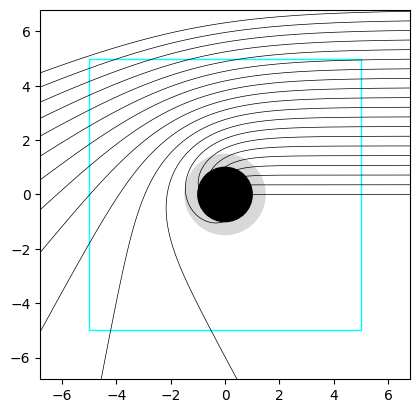

In [4]:
# Initialising the box with a certain size. Make sure the source you have 
# fits inside this box.
box = Box(box_size=10, box_points=100, viewing_angles=(0,0))

# We then calculate the photon rays for different impact parameters.
box.calculate_photon_rays(n_b=20, metric=metric, D=1000, b_max=6.8)
# And plotting these calculated photon rays
box.plot_box_orbits()

When choosing values for box_points and n_b (and later n_alpha) ensure that 
box_points is larger than either of these two values (ideally by an order 
of magnitude).

Additionally, the blue contour indicates the size of the box. The value of b_max
should be taken slightly larger than box_size / 2 to ensure that the entire box 
is covered by photon rays. This can be done by trial and error with a low n_b
and plotting the rays as above.

## Combining to generate an image

This is the place to add the source you defined to the box! Check the output
picture to see if the source has the shape you would expect. Note that for the
picture generation, we are looking at it from above.

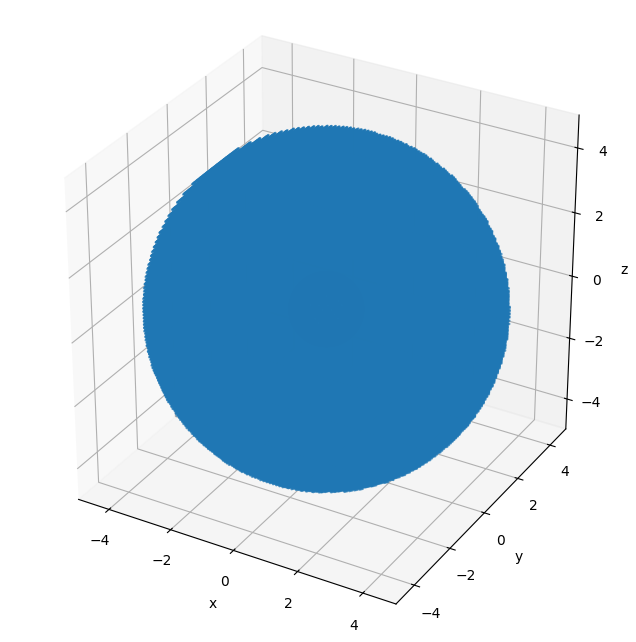

In [5]:
# We add our source to the box, change "sphere" to a different variable if you
# have defined a different source
box.clear_sources()
box.add_source(sphere)
# And we can plot it to check the orientation
box.plot_source()

Finally, we can generate the simulated image with the cells below. Give it a suitable name to save it such that you can remember what the parameters were that you used! You can change the log=False option to log=True to see if this displays the features better. In different cases either might work best. However, when comparing two pictures, make sure they use the same option! Similarly, you can change the number for the smoothing.

In [6]:
# We can finally calculate the pixel brightness and plot the resulting image
box.calculate_pixel_brightness(n_alpha=20)

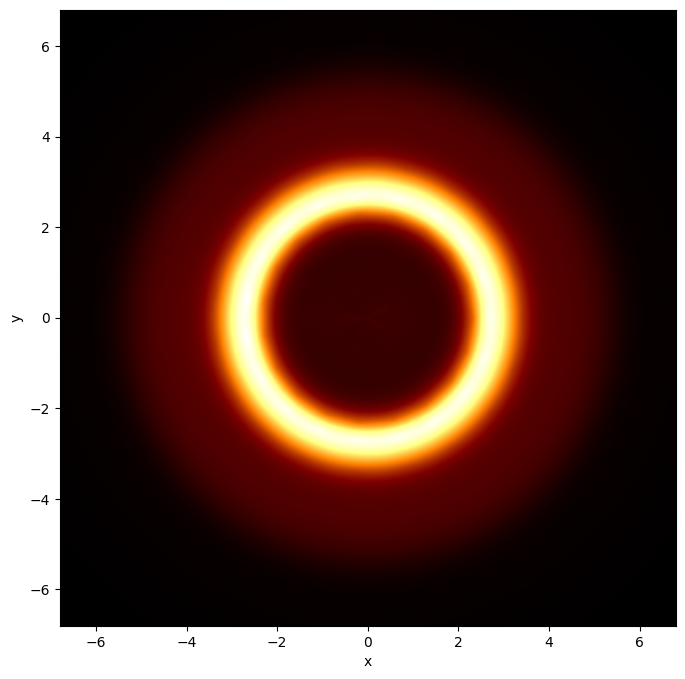

In [7]:
box.plot_image(smoothing=1, log=False, imsave='') 
# Change imsave to where you want to save the picture!